# DAY 2 — 첫 기준 모델

이번 단계에서는 어제 결정한 선형·규제 회귀 전략 중 **단순 선형회귀 기준 모델**을 만든다.
Ridge·Elastic Net의 개선 여부를 비교할 출발점이다.

| 항목 | 사용자 확정 사항 |
| --- | --- |
| 예측 단위 | 배터리 셀 한 개당 한 행 |
| 입력 | 첫 100사이클에서 얻은 `delta_q_log10var` 하나 |
| 타깃 | 원본 최종 `cycle_life`, 단위는 사이클 |
| 개발 데이터 | Batch 1 |
| 분할 | 동일 충전 조건 그룹 분리, 그룹 20% Hold-out |
| CV | 남은 개발 부분에서 5-fold 그룹 CV, seed 42 |

`delta_q_log10var = log10(var(Qdlin_100 − Qdlin_10))`이다.
어제 계산한 각 셀의 1,000개 전압 지점 차이를 한 개의 통계값으로 요약한 입력이며,
최종 수명이나 전체 열화 곡선을 입력으로 넣지 않는다.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/modeling_baseline.py').exists()
             and (p / 'outputs/day1/early_feature_candidates.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('현재 battery-project의 루트 또는 notebooks/에서 실행하세요.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.modeling_baseline import prepare_splits, run

print(f'프로젝트: {ROOT}')
print(f'Python {sys.version.split()[0]} / scikit-learn {sklearn.__version__}')

프로젝트: /Users/lwh/Desktop/battery-project
Python 3.12.13 / scikit-learn 1.9.1


## 1. 학습에 들어갈 열 확인

어제 저장한 피처 후보 표에서 Batch 1만 가져온다.
`cell_id`와 `policy_readable`은 셀 확인·분할에 사용하며 모델 입력은 **ΔQ log분산 한 열**이다.
표준화의 평균·표준편차를 계산하기 전에 분할을 먼저 확정한다.

In [2]:
candidates = pd.read_csv(ROOT / 'outputs/day1/early_feature_candidates.csv')
batch1 = candidates.loc[candidates['batch_id'].eq('batch1')].sort_values('cell_id').copy()
input_column = 'delta_q_log10var'
target_column = 'cycle_life'
display(batch1[['cell_id', 'policy_readable', input_column, target_column]].head())
print(f'Batch 1: {len(batch1)}셀 / 충전 조건 {batch1.policy_readable.nunique()}그룹')
assert len(batch1) == 46
assert np.isfinite(batch1[[input_column, target_column]].to_numpy()).all()

,cell_id,policy_readable,delta_q_log10var,cycle_life
0,0,3.6C(80%)-3.6C,-5.014861,1190.0
1,1,3.6C(80%)-3.6C,-5.013960,1179.0
2,2,3.6C(80%)-3.6C,-4.737000,1177.0
3,3,4C(80%)-4C,-4.442613,1226.0
4,4,4C(80%)-4C,-4.647744,1227.0


Batch 1: 46셀 / 충전 조건 23그룹


## 2. 그룹 Hold-out과 CV 분할 고정

같은 충전 조건의 셀은 학습 쪽과 검증 쪽에 동시에 들어가지 않는다.
20%는 **그룹 수** 기준이므로 셀 수의 정확한 20%와 다를 수 있다.
나머지 개발 셀에서 CV를 수행하며, 각 개발 셀은 다섯 번 중 한 번 검증 대상이 된다.

이 셀은 분할만 저장한다. 저장된 분할은 이후 모델 비교에서도 재사용한다.

In [3]:
splits = prepare_splits(ROOT)
display(splits['split_summary'][['partition', 'n_cells', 'n_protocol_groups']])
display(splits['fold_summary'])
display(splits['assignments'].head(10))

,partition,n_cells,n_protocol_groups
0,development,35,18
1,holdout,11,5


,fold,n_train_cells,n_validation_cells,n_train_groups,n_validation_groups
0,1,28,7,14,4
1,2,27,8,14,4
2,3,27,8,14,4
3,4,29,6,15,3
4,5,29,6,15,3


,batch_id,cell_id,policy_readable,partition,cv_validation_fold
0,batch1,0,3.6C(80%)-3.6C,holdout,<NA>
1,batch1,1,3.6C(80%)-3.6C,holdout,<NA>
2,batch1,2,3.6C(80%)-3.6C,holdout,<NA>
3,batch1,3,4C(80%)-4C,development,3
4,batch1,4,4C(80%)-4C,development,3
5,batch1,5,4.4C(80%)-4.4C,development,1
6,batch1,6,4.8C(80%)-4.8C,development,1
7,batch1,7,4.8C(80%)-4.8C,development,1
8,batch1,8,5.4C(40%)-3.6C,development,2
9,batch1,9,5.4C(40%)-3.6C,development,2


## 3. 첫 선형회귀의 CV 성능 계산

각 fold에서 **StandardScaler → LinearRegression** 순서로 학습한다.
표준화의 기준도 해당 fold의 train 셀에서만 계산한다.
선형회귀는 ΔQ log분산과 수명의 관계를 직선으로 표현한다.

주 지표는 **5개 fold의 MAPE(%) 산술평균**이다. 작은 개발 표본에서 분할별 성능이 얼마나
달라지는지 표본 표준편차도 함께 확인한다. MAE·RMSE는 사이클 단위의 보조 지표다.

In [4]:
baseline = run(ROOT)
display(baseline['fold_metrics'])
summary = baseline['summary']
primary, auxiliary = summary['primary'], summary['auxiliary']
display(pd.DataFrame([
    {'구분': 'Train (Batch 1 CV)', 'MAPE (%)': f"{primary['mape_percent_mean']:.2f}",
     '비고': '개발 부분의 5-fold validation 평균'},
    {'구분': 'Valid (Batch 1 Hold-out)', 'MAPE (%)': '미평가', '비고': '후보 선택 후 평가'},
    {'구분': 'Test (Batch 2)', 'MAPE (%)': '미평가', '비고': '설정 확정 후 최종 평가'},
]))
display(Markdown(
    f"**CV MAPE {primary['mape_percent_mean']:.2f}% · fold 간 표본 SD {primary['mape_percent_sample_sd']:.2f}%p**\n\n"
    f"보조 지표: fold 평균 MAE {auxiliary['mae_cycles_fold_mean']:.1f}사이클, "
    f"RMSE {auxiliary['rmse_cycles_fold_mean']:.1f}사이클. "
    'SD는 분할 간 변동이며 신뢰구간이 아니다.'
))

,fold,n_train_cells,n_validation_cells,n_train_groups,n_validation_groups,mape_percent,mae_cycles,rmse_cycles
0,1,28,7,14,4,10.386223,83.001157,105.819363
1,2,27,8,14,4,5.949656,52.342971,67.551765
2,3,27,8,14,4,6.145374,53.177946,60.586704
3,4,29,6,15,3,4.472865,34.650230,40.836428
4,5,29,6,15,3,9.244854,77.531902,86.506398


,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.24,개발 부분의 5-fold validation 평균
1,Valid (Batch 1 Hold-out),미평가,후보 선택 후 평가
2,Test (Batch 2),미평가,설정 확정 후 최종 평가


**CV MAPE 7.24% · fold 간 표본 SD 2.47%p**

보조 지표: fold 평균 MAE 60.1사이클, RMSE 72.3사이클. SD는 분할 간 변동이며 신뢰구간이 아니다.

## 4. 검증 예측과 오차 읽기

CV 검증 예측은 해당 셀을 학습에 넣지 않은 모델의 예측이다.
훈련 데이터에 다시 예측한 적합 성능과 구분한다.
왼쪽은 fold별 오차, 오른쪽은 실제 수명과 CV 예측 수명이다.

,batch_id,cell_id,policy_readable,cv_validation_fold,y_true_cycle_life,y_pred_cycle_life,absolute_error_cycles,absolute_percentage_error_percent
0,batch1,3,4C(80%)-4C,3,1226.0,1144.728060,81.271940,6.629033
1,batch1,4,4C(80%)-4C,3,1227.0,1258.450337,31.450337,2.563190
2,batch1,5,4.4C(80%)-4.4C,1,1074.0,1011.410307,62.589693,5.827718
3,batch1,6,4.8C(80%)-4.8C,1,636.0,783.193946,147.193946,23.143702
4,batch1,7,4.8C(80%)-4.8C,1,870.0,808.023981,61.976019,7.123680


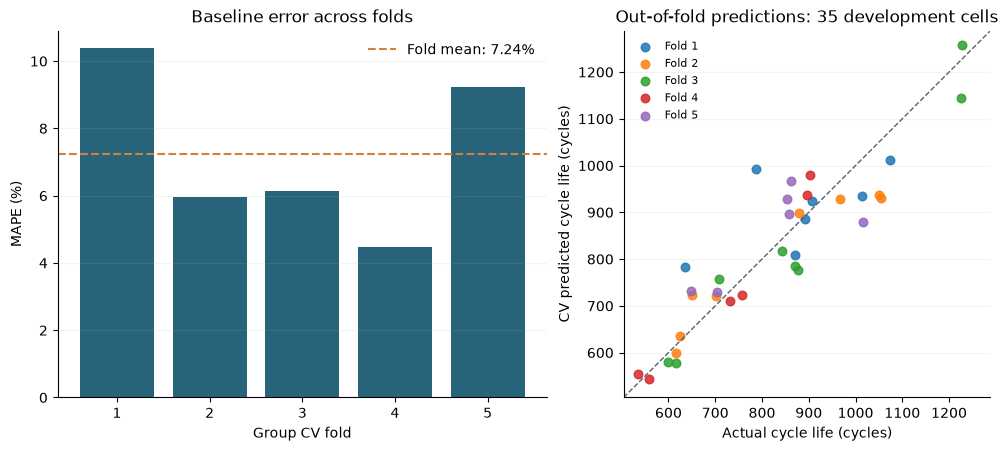

왼쪽의 점선은 fold 평균이다. 오른쪽 점선에 가까울수록 실제 수명과 예측이 일치한다. 각 점은 해당 셀과 같은 충전 조건을 학습에서 제외한 CV 예측이다.

In [5]:
fold_metrics = baseline['fold_metrics']
cv_predictions = baseline['cv_predictions']
display(cv_predictions.head())
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), constrained_layout=True)
axes[0].bar(fold_metrics['fold'], fold_metrics['mape_percent'], color='#27647B')
axes[0].axhline(primary['mape_percent_mean'], color='#D58037', linestyle='--',
                label=f"Fold mean: {primary['mape_percent_mean']:.2f}%")
axes[0].set(xlabel='Group CV fold', ylabel='MAPE (%)',
            title='Baseline error across folds')
axes[0].set_xticks(fold_metrics['fold'])
axes[0].set_ylim(bottom=0)
axes[0].legend(frameon=False)

for fold, points in cv_predictions.groupby('cv_validation_fold'):
    axes[1].scatter(points['y_true_cycle_life'], points['y_pred_cycle_life'],
                    label=f'Fold {fold}', s=38, alpha=0.85)
values = cv_predictions[['y_true_cycle_life', 'y_pred_cycle_life']].to_numpy()
lo, hi = values.min() - 30, values.max() + 30
axes[1].plot([lo, hi], [lo, hi], color='#53616C', linestyle='--', linewidth=1)
axes[1].set(xlim=(lo, hi), ylim=(lo, hi), xlabel='Actual cycle life (cycles)',
            ylabel='CV predicted cycle life (cycles)',
            title=f'Out-of-fold predictions: {len(cv_predictions)} development cells')
axes[1].set_aspect('equal', adjustable='box')
axes[1].legend(frameon=False, fontsize=8)
for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
    axis.grid(axis='y', alpha=0.15)
figure_dir = ROOT / 'outputs/day2'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'v01_baseline_cv.png', dpi=180, bbox_inches='tight')
plt.show()
display(Markdown('왼쪽의 점선은 fold 평균이다. 오른쪽 점선에 가까울수록 실제 수명과 예측이 일치한다. '
                 '각 점은 해당 셀과 같은 충전 조건을 학습에서 제외한 CV 예측이다.'))

## 5. 개발 부분에 학습한 기준 모델

다섯 fold의 성능을 계산한 후, 남은 개발 셀 전체에 같은 기준 모델을 학습해 저장한다.
계수 표는 표준화를 원래 입력 단위로 환산한 값도 제공한다.
이 계수는 개발 데이터의 연관성을 표현하며 인과 효과를 뜻하지 않는다.

In [6]:
coefficient = baseline['coefficients'].loc[
    baseline['coefficients']['stage'].eq('development_baseline')]
display(coefficient[['n_fit_cells', 'feature', 'coefficient_original_input_units',
                     'intercept_original_input_units']])
print(coefficient['equation'].iloc[0])
print('저장 위치:', ROOT / 'artifacts/experiments/v01_baseline')

,n_fit_cells,feature,coefficient_original_input_units,intercept_original_input_units
5,35,delta_q_log10var,-551.089766,-1297.907597


predicted_cycle_life = -1297.90759666 + (-551.089766153) * delta_q_log10var
저장 위치: /Users/lwh/Desktop/battery-project/artifacts/experiments/v01_baseline


## 다음 단계

확장 피처 구성과 Ridge·Elastic Net 규제 강도의 탐색 방법을 사용자와 정한 뒤,
같은 개발 분할에서 기준 모델과 비교한다. 별도 Hold-out과 Batch 2·3 평가는
후보·설정을 선택한 뒤 수행한다. 이 노트북의 현재 범위는 첫 기준 모델의 CV까지다.

분할 API 참고: [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html),
[GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html).